

# Identifying the Risk of Depression and Optimizing the Timing of Intervention
### Behavioral Patterns as a Basis for Intervention Decisions

---

## I. Contexto y Justificación

## 1. El Problema

La depresión es uno de los trastornos mentales más prevalentes y discapacitantes a nivel mundial. Según la OMS, afecta a más de 280 millones de personas y se proyecta como la principal causa de discapacidad global para 2030. Sin embargo, y a pesar de décadas de investigación clínica, sigue siendo un trastorno con un problema estructural no resuelto: **se detecta tarde**.

La evaluación clínica estándar de la depresión se basa en instrumentos psicométricos validados, siendo el **PHQ-9** y el **BDI-II** los más utilizados. El PHQ-9 es un cuestionario de autoinforme de 9 ítems, desarrollado por Kroenke, Spitzer y Williams en 2001, que evalúa directamente los nueve criterios diagnósticos del DSM para el trastorno depresivo mayor. La persona indica con qué frecuencia ha experimentado cada síntoma durante las **últimas dos semanas**, en una escala de 0 a 3. El BDI-II, desarrollado por Beck y colaboradores, es un instrumento de 21 ítems con el mismo marco temporal y rango de respuesta. Ambos instrumentos tienen propiedades psicométricas sólidas, están ampliamente validados en distintas poblaciones y culturas, y son herramientas de referencia tanto en clínica como en investigación.

El problema no es que estos instrumentos sean malos. El problema es para qué están diseñados y para qué no. Están diseñados para medir la severidad de los síntomas en un momento dado, una vez que esos síntomas ya son suficientemente perceptibles para que la persona los reporte. No están diseñados para detección temprana, y no pueden serlo por su naturaleza: son puntuales, episódicos y dependen íntegramente del autoinforme.

El autoinforme tiene limitaciones estructurales en este contexto. Para que el instrumento funcione, la persona debe percibir sus propios síntomas, recordarlos con precisión retrospectiva durante dos semanas, y estar dispuesta a reportarlos honestamente. Ninguna de estas condiciones se cumple de forma fiable en depresión. El deterioro temprano ocurre gradualmente y por debajo del umbral de conciencia del paciente. La memoria retrospectiva de dos semanas está sujeta a sesgos sistemáticos documentados. Y el estigma del trastorno hace que el autoinforme infraestime consistentemente la severidad real: investigación experimental con el BDI-II ha mostrado que tanto hombres como mujeres reportan significativamente más síntomas depresivos cuando el propósito del cuestionario está enmascarado, lo que sugiere que las encuestas de comunidad subestiman la prevalencia real.

> **Implicación para la validación:** si la detección conductual y el autoinforme no coinciden, eso no prueba que la detección falle. Puede significar que la señal conductual captura algo que el autoinforme no recoge, o que lo recoge con retraso. Esta ambigüedad es una consecuencia esperada de comparar una señal continua y objetiva con una medida puntual y subjetiva.

Existe un hueco clínico concreto: hay un periodo de deterioro progresivo, observable en el comportamiento, que los sistemas actuales no capturan. Durante ese periodo, una intervención temprana sería más eficaz que cualquier intervención reactiva. **Este proyecto apunta a ese hueco.**


## 2. Lo que se ha intentado y por qué no ha funcionado

En la última década ha emergido un campo de investigación que intenta aprovechar los datos pasivos de smartphones y wearables para monitorizar el estado mental de forma continua y no invasiva. Los estudios iniciales entre 2014 y 2019 mostraron correlaciones prometedoras entre señales de localización, actividad, sueño y uso del móvil con medidas clínicas de depresión. Sin embargo, todos compartían una limitación metodológica grave: muestras pequeñas, periodos cortos, y evaluación en los mismos datos de entrenamiento. Los resultados publicados eran optimistas, pero no generalizables.

Para abordar este problema, un equipo de investigadores de la Universidad de Washington desarrolló el dataset **GLOBEM** (*Generalization of Longitudinal Behavior Modeling*), actualmente la referencia más completa y rigurosa en el campo del modelado longitudinal de comportamiento humano para salud mental. GLOBEM agrupa cuatro estudios anuales consecutivos de 2018 a 2021, diez semanas por estudio, con **705 person-years y 497 participantes únicos**, estudiantes de pregrado reclutados con sobrerrepresentación intencionada de grupos minoritarios. Cada año, los participantes instalaron una aplicación en su móvil y llevaron un Fitbit, que recogieron de forma pasiva señales de actividad, sueño, localización, uso de pantalla, llamadas y proximidad bluetooth. Simultáneamente, completaron cuestionarios semanales de estado depresivo y evaluaciones clínicas al inicio y al final de cada estudio.

Lo que hace a GLOBEM especialmente valioso no es solo su tamaño, sino su diseño: al tener cuatro años de datos de diferentes cohortes, permite evaluar si los modelos generalizan no solo entre personas, sino también entre años y contextos distintos, incluyendo el impacto del COVID en los datos de 2020 y la recuperación progresiva en 2021. Es el primer dataset público que permite medir de forma rigurosa la generalización de los algoritmos de detección conductual a escala multianual.

Los resultados del benchmark son contundentes:

- **18 algoritmos** evaluados: los 9 modelos de detección de depresión más citados en literatura + 8 algoritmos de generalización de dominio
- El mejor algoritmo alcanza un **54.7% de precisión** en datos no vistos — apenas 9.7 puntos sobre predecir siempre la clase mayoritaria
- La diferencia con los resultados publicados en papers originales: **18.9 puntos porcentuales de media**

Los propios autores identifican la causa: **las diferencias individuales son probablemente el factor más determinante del fracaso**. Lo que para una persona es señal de deterioro, para otra es su estado habitual. Un modelo entrenado para comparar personas entre sí no puede capturar eso.

Existe, sin embargo, un segundo problema que el benchmark no aborda: el de la variable objetivo. Los 18 algoritmos evaluados utilizaron como target las puntuaciones de cuestionarios de autoinforme, PHQ-4 y BDI-II, como si estas fueran una medida fiable del deterioro. Pero estas etiquetas no describen un proceso: describen cómo se siente alguien en un momento dado, una vez que los síntomas ya son suficientemente perceptibles para ser reportados. Predecir esa etiqueta no es lo mismo que detectar el cambio progresivo que la precede. A esto se añade un problema de resolución temporal: el PHQ-4 se administraba de forma continua durante el estudio, mientras que el BDI-II se recogía una única vez al final. Usarlos como si fueran equivalentes para construir el target introduce ruido metodológico, porque no están midiendo lo mismo ni en el mismo momento. Este problema es independiente del de generalización, y este proyecto lo aborda de forma separada.


## 3. Por qué el enfoque intra-sujeto es la respuesta

Si el problema es que cada persona es diferente, la solución no es entrenar modelos más sofisticados. Es cambiar la pregunta. En lugar de preguntar *¿se parece esta persona al perfil de alguien con depresión?*, la pregunta correcta es: **¿está esta persona alejándose de su propio patrón habitual de funcionamiento?**

Comparar a cada persona consigo misma en lugar de con el grupo: eso es el **enfoque intra-sujeto**.

No es una propuesta completamente nueva. Algunos estudios han empezado a construir modelos individuales o a normalizar señales por la media histórica de cada persona. La investigación en digital phenotyping señala explícitamente la personalización como una de las direcciones más prometedoras. Pero estos enfoques mantienen un foco clasificatorio: siguen prediciendo si alguien tiene o no depresión usando la etiqueta clínica como target.

**Lo que este proyecto propone es diferente:** detectar y cuantificar la desviación respecto al baseline individual como señal de alerta en sí misma, sin necesidad de una etiqueta clínica. El sistema no termina en una predicción. Termina en una decisión:

*¿Cuándo es la desviación suficientemente sostenida como para justificar intervención?*

La diferencia entre *"esta persona probablemente tiene depresión"* y *"esta persona lleva dos semanas alejándose de su patrón habitual de una forma que merece atención"*.

**El hueco que este proyecto ocupa:** a fecha de este trabajo, ningún estudio publicado ha implementado un enfoque intra-sujeto completo sobre el dataset GLOBEM. Los propios autores señalan que las diferencias individuales son probablemente la causa principal del fracaso de generalización, y la literatura reciente en digital phenotyping coincide en que la personalización es la dirección más prometedora. Sin embargo, los trabajos publicados hasta ahora —incluyendo estudios de 2024 y 2025 sobre imputación de datos, estrategias de generalización y fenotipos digitales— siguen operando dentro del paradigma poblacional: entrenar modelos sobre unas personas y probarlos en otras. La pregunta *¿Esta persona se está alejando de su propio patrón?* no se ha encontrdo formulada en las investigaciones con estos datos. Este proyecto la formula y la operacionaliza.



## 4. Las señales que usamos y por qué

El dataset GLOBEM recoge señales pasivas mediante Fitbit y una app móvil basada en el framework AWARE, que captura localización, estado de pantalla, llamadas y bluetooth. El Fitbit captura actividad y sueño. Las señales fueron procesadas con **RAPIDS**, herramienta de extracción de features para datos de sensing pasivo, que genera variables agregadas con distintas ventanas temporales y franjas horarias.

Las cuatro señales núcleo de este proyecto son **actividad física, sueño, movilidad y comportamiento de pantalla**. La elección tiene respaldo empírico directo:

- Según el análisis de correlación del propio dataset GLOBEM, la **duración del sueño** en las últimas dos semanas y el **número de desbloqueos de pantalla durante la noche** son las señales con la correlación más fuerte con las puntuaciones de depresión.
- El análisis del dataset indica que los participantes con puntuaciones más altas tendían a tener **menos actividad física, menor movilidad y más tiempo en casa**.
- La literatura respalda la reducción de actividad motora como indicador de riesgo previo a síntomas clínicos, y el comportamiento de pantalla nocturno como marcador de alteraciones circadianas asociadas al inicio de los síntomas depresivos.

Estas cuatro señales son observables de forma pasiva, continua y sin carga para el participante, y tienen **significado conductual interpretable**. Un sistema orientado a decisiones necesita poder explicar qué ha cambiado y por qué eso merece atención.



## 5. Implicación práctica y transferibilidad

Este sistema no está concebido como un modelo aislado ni como un ejercicio académico. Está diseñado para integrarse como capa funcional dentro de plataformas reales de salud digital.

**Aplicación directa en plataformas existentes**

El mercado de salud mental digital ha crecido significativamente en los últimos años. Plataformas como Wysa, Headspace, Meru Health o Woebot ofrecen intervenciones basadas en terapia cognitivo-conductual, mindfulness y apoyo emocional, combinando chatbots con acceso a profesionales. Algunas integran datos de wearables y sensores pasivos del móvil. Estas plataformas ya recogen datos de uso: frecuencia de sesiones, horarios de acceso, patrones de interacción, duración de uso. Lo que no tienen es un sistema que detecte automáticamente cuándo un usuario está empezando a deteriorarse para activar una intervención antes de que el deterioro se consolide.

Un sistema como el que se construye en este proyecto permitiría a este tipo de plataformas pasar de un modelo reactivo (el usuario busca ayuda cuando ya se siente mal) a un modelo anticipatorio (la plataforma detecta cambio conductual sostenido y activa intervención proactiva). Esa transición tiene impacto directo en tres niveles: para la persona (intervención más temprana y eficaz), para la plataforma (mayor retención y valor clínico demostrable) y para el sistema de salud (reducción de costes por intervención tardía).

Además, los datos que recogen estas plataformas ya están dentro de un entorno de tratamiento: el usuario ha dado su consentimiento, los datos son parte de su proceso de acompañamiento, y no requieren un dispositivo adicional ni una recogida de datos fuera del contexto clínico. Esto resuelve uno de los problemas prácticos de la monitorización pasiva: la viabilidad ética y legal del acceso a datos personales de comportamiento.

**Transferibilidad a otros dominios**

Pero el alcance del sistema va más allá de la salud mental. La lógica que se construye aquí —baseline individual, medición de desviación sostenida, convergencia entre dimensiones conductuales y umbral de intervención— es transferible a cualquier dominio donde el comportamiento humano sea la señal y la detección temprana de cambio tenga valor práctico:

- **Producto digital:** detectar usuarios cuyo patrón de uso se aleja de su comportamiento habitual (frecuencia, profundidad, horarios) como señal temprana de churn, antes de que el abandono se materialice.

- **Rendimiento laboral o educativo:** identificar cambios sostenidos en patrones de actividad, comunicación o entrega que anticipen deterioro de rendimiento, sin depender de evaluaciones periódicas.

- **Salud crónica:** monitorizar desviaciones en actividad, sueño o movilidad en pacientes con condiciones crónicas como señal de descompensación antes de que requiera atención urgente.

- **Cualquier sistema de monitorización longitudinal:** donde se disponga de datos pasivos sobre comportamiento individual y la pregunta relevante sea *¿Esta persona está cambiando respecto a sí misma de una forma que merece atención?*

La depresión es el dominio de aplicación de este proyecto. El sistema que se construye es más general. 




---

## II. Problem Framing

### 1. Por qué definir deterioro es la decisión más importante de este proyecto

Antes de construir cualquier baseline, antes de calcular cualquier desviación, antes de elegir cualquier algoritmo, hay una decisión que condiciona todo lo demás: qué entendemos exactamente por deterioro.

Esta decisión no es técnica. Es conceptual y estructural. Todo lo que viene después —las variables que se usan, cómo se transforman, cómo se combinan y cómo se interpreta el resultado— depende de cómo se defina ese punto de partida. Si la definición es débil, ambigua o equivocada, el sistema completo hereda ese problema. Puede ser técnicamente correcto y, aun así, estar resolviendo algo distinto de lo que se pretende.

El error más habitual en este tipo de proyectos es aceptar la definición que viene dada. El dataset incluye etiquetas clínicas, puntuaciones como PHQ o BDI, variables binarias que indican presencia de síntomas. La tentación es utilizarlas directamente como target. Sin embargo, esas etiquetas no describen el proceso que se quiere detectar. Son mediciones puntuales, dependientes de autoinforme, y en muchos casos reflejan estados ya consolidados. Utilizarlas como definición de deterioro equivale a construir un sistema que predice autopercepción en momentos concretos, no uno que detecta el cambio progresivo que conduce a ese estado.

La pregunta relevante no es qué etiqueta está disponible, sino **qué proceso se quiere capturar y cómo se manifiesta en los datos antes de que sea clínicamente evidente**.

Ese proceso no es observable de forma directa. No existe una variable única que indique deterioro. Lo disponible son señales conductuales parciales: actividad física, movilidad, patrones de sueño, uso del dispositivo. Cada una puede cambiar por múltiples motivos sin relación con deterioro. Una caída en la actividad puede deberse a una lesión. Un cambio en el sueño puede deberse a estrés puntual o a un viaje. Un aumento en el uso del móvil puede estar asociado a trabajo o a ocio. Ninguna de estas señales, tomada de forma aislada, permite inferir deterioro de forma fiable.

El problema real no es identificar cambios en variables individuales, sino **distinguir entre variabilidad normal del comportamiento y cambios que reflejan una alteración real del funcionamiento de la persona**.

Para que esa distinción sea defendible, la definición de deterioro debe cumplir tres condiciones que se desarrollan en detalle en las secciones siguientes:

- **Relativa al baseline individual.** No interesa el nivel absoluto de una variable, sino su desviación respecto al patrón habitual de esa persona. El sistema no compara individuos entre sí, sino a cada individuo consigo mismo a lo largo del tiempo.

- **Convergente.** El deterioro no se define por un cambio en una sola dimensión, sino por la aparición simultánea de cambios en varias dimensiones conductuales. La combinación de señales reduce la probabilidad de explicaciones alternativas basadas en una única causa puntual.

- **Persistente.** Los cambios puntuales forman parte del comportamiento normal. Para que una señal sea interpretable, debe mantenerse en el tiempo lo suficiente como para descartar ruido o eventos transitorios.

Estas tres condiciones no eliminan completamente las fuentes de confusión, pero permiten construir una definición operativa que es robusta frente a ellas sin necesidad de modelar explícitamente cada causa alternativa.

A partir de esta definición, el deterioro deja de entenderse como una etiqueta estática y pasa a conceptualizarse como un **proceso dinámico**: un cambio sostenido en el patrón de funcionamiento de una persona, observable a través de la evolución conjunta de sus señales conductuales.

En este contexto, los cuestionarios no se utilizan para definir el deterioro, sino para contrastarlo. Su papel es aportar una referencia externa, sabiendo que es imperfecta. No pueden actuar como verdad, sino como un elemento más en la evaluación del sistema.

Lo que se construye en este proyecto es una **definición conductual del deterioro basada en datos longitudinales**, independiente de etiquetas clínicas directas y orientada a detectar cambios antes de que estos se formalicen en una medición clínica.

Lo que sigue es el desarrollo explícito de esa definición y su traducción a una estructura operativa.

## 2. Análisis de contaminantes por dimensión conductual

Antes de definir qué es deterioro, hay que entender qué más puede producir los mismos patrones en los datos. Cada señal disponible está expuesta a causas alternativas que no tienen relación con deterioro. Si no se identifican y se tiene en cuenta cómo afectan a la definición, el sistema detectará cambios reales pero interpretará mal su origen.

El análisis que sigue no pretende eliminar cada contaminante uno por uno. Eso sería imposible con los datos disponibles. El objetivo es entender la naturaleza del ruido en cada dimensión, para diseñar una definición que sea robusta frente a él por construcción.

**Actividad física y movilidad**

Una caída en la actividad física puede deberse a enfermedad puntual, lesión, fatiga acumulada, periodos de alta carga académica o laboral, mal tiempo, o simplemente a días de descanso intencionado. Una reducción de movilidad puede reflejar teletrabajo, vacaciones, cambio de horarios, o hábitos personales más domésticos sin ningún correlato de deterioro.

El problema conceptual aquí es que menos actividad no significa automáticamente apatía o retirada funcional. Puede significar cansancio, enfermedad o cambio de contexto. Esta dimensión por sí sola tiene baja especificidad.

**Sueño y regularidad de patrones diarios**

El sueño es la señal más sensible del conjunto, pero también la más expuesta a contaminantes. Enfermedad, estrés puntual, exámenes, viajes, jet lag, consumo de cafeína, alcohol o medicación, trabajo a turnos, o simplemente los fines de semana pueden alterar los patrones de sueño sin que haya ningún deterioro subyacente. La irregularidad de ritmos puede reflejar simplemente una vida menos estructurada por motivos externos.

**Uso pasivo — comportamiento de pantalla nocturno**

Un aumento en el uso nocturno del móvil puede deberse a trabajo, estudio, ocio, ver series, cambio de hábitos digitales, o periodos de insomnio no relacionados con deterioro emocional. Más pantalla nocturna no es necesariamente una señal de activación circadiana alterada por deterioro.

**La conclusión que estructura todo lo que sigue**

Ninguna de estas dimensiones, analizada de forma independiente, permite inferir deterioro de forma fiable. Esto no invalida las señales: invalida el enfoque de mirarlas por separado. La definición de deterioro debe emerger de la combinación de señales, diseñada para que sea difícil de explicar por causas alternativas aisladas.



## 3. Los tres criterios: persistencia, convergencia y baseline individual

Los tres criterios que estructuran la definición de deterioro en este proyecto no son convenciones arbitrarias. Son respuestas directas al problema de contaminación identificado en la sección anterior. Cada criterio elimina una clase de ruido que los otros no cubren.

**Persistencia**

Un cambio de uno o dos días en cualquier dimensión conductual puede ser cualquier cosa: un mal día, una enfermedad puntual, un fin de semana diferente. Ningún sistema que dispare alertas ante cambios de esta duración tendría utilidad práctica porque generaría falsas alarmas de forma constante.

La persistencia temporal exige que el cambio se mantenga durante al menos **siete días consecutivos** para ser considerado relevante. Este umbral no es arbitrario. Siete días es coherente con las ventanas temporales que ya calcula RAPIDS en el dataset. Es suficientemente largo para filtrar la mayoría de los contaminantes puntuales. Y es suficientemente corto para ser anticipatorio: el criterio clínico del DSM para hablar de episodio depresivo exige dos semanas. Este sistema apunta a detectar lo que ocurre antes de ese umbral.

La persistencia sola no es suficiente. Un resfriado prolongado también puede mantenerse siete días y reducir la actividad. Por eso necesita combinarse con los otros dos criterios.

**Convergencia entre dimensiones**

Si solo se ve afectada una dimensión durante siete días, todavía hay demasiadas explicaciones alternativas posibles. Una lesión puede reducir la actividad y la movilidad durante semanas sin que haya ningún deterioro emocional. Un periodo de exámenes puede alterar el sueño de forma sostenida.

La convergencia exige que el cambio sea simultáneo en **al menos dos de las tres dimensiones conductuales**: activación, sueño y uso pasivo. Cuando dos dimensiones se alteran a la vez de forma sostenida, la probabilidad de que una única causa puntual lo explique todo disminuye significativamente.

Se exige convergencia en dos de tres, no en las tres, por dos razones. Primera: el dataset tiene ruido de medición. Hay días donde el wearable no se llevó puesto o el sensor falló. Exigir las tres dimensiones siempre significaría perder casos reales por fallos técnicos. Segunda: el deterioro no tiene una expresión universal. En algunas personas la primera señal es el sueño. En otras es la actividad. Exigir las tres a la vez reproduciría el mismo error de los modelos poblacionales: asumir que todos se deterioran de la misma manera.

**Desviación respecto al baseline individual**

Los dos criterios anteriores trabajan sobre cambios relativos, no sobre valores absolutos. Eso requiere una referencia. Esa referencia no puede ser la media del grupo porque las personas son muy distintas entre sí: hay personas que duermen poco y eso es su estado normal; hay personas muy sedentarias para las que eso no representa ningún cambio.

El baseline individual es el patrón habitual de funcionamiento de cada persona, construido a partir de sus propios datos durante un periodo estable al inicio del estudio. La desviación no se mide contra una norma externa, sino contra la norma propia de cada individuo.

Este criterio es el que hace que el sistema sea intra-sujeto por construcción. No compara personas. Compara a cada persona consigo misma a lo largo del tiempo.

**Los tres criterios operan juntos**

Ninguno de los tres criterios es suficiente por sí solo. La persistencia sin convergencia detecta cambios sostenidos en una sola dimensión, que pueden tener explicaciones alternativas claras. La convergencia sin persistencia detecta coincidencias puntuales entre dimensiones, que pueden ser ruido. El baseline individual sin los otros dos criterios simplemente mide variabilidad, sin distinguir si es relevante.

Es la combinación de los tres lo que produce una señal que es más difícil de explicar por causas alternativas y que tiene coherencia como indicador de un posible deterioro funcional real.

## 4. Definición formal operativa

A partir del análisis anterior, la definición operativa que guía este proyecto es la siguiente:

**Deterioro conductual = desviación sostenida durante al menos 7 días, respecto al baseline individual, convergente en al menos 2 de las 3 dimensiones conductuales: activación, sueño y uso pasivo.**

Esta definición tiene cuatro propiedades que conviene hacer explícitas. 

**Es relativa, no absoluta.** No hay un nivel de actividad, sueño o uso de pantalla que sea en sí mismo deterioro. Lo que importa es el alejamiento de la normalidad propia de cada persona.

**Es conductual, no clínica.** No depende de etiquetas diagnósticas ni de autoinforme. Se construye íntegramente a partir de señales pasivas y longitudinales. Las puntuaciones de cuestionarios como PHQ o BDI no forman parte de la definición: son una referencia externa para contrastar el sistema, no para construirlo.

**Es dinámica, no estática.** No etiqueta a una persona como deteriorada o no deteriorada en un momento dado. Describe un proceso: el cambio sostenido en el patrón de funcionamiento de una persona a lo largo del tiempo.

**Es operativa con los datos disponibles.** Cada uno de sus componentes —baseline individual, desviación por dimensión, persistencia temporal, convergencia entre dimensiones— puede calcularse directamente a partir de las features que proporciona el dataset GLOBEM a través de RAPIDS.

Lo que esta definición no garantiza es que todos los casos detectados sean deterioro clínico en el sentido diagnóstico. Lo que sí garantiza es que los casos detectados son difícilmente explicables por contaminantes puntuales, y que cuando no coincidan con el autoinforme, la primera hipótesis razonable no será que el sistema falla, sino que está detectando algo que el autoinforme no ha capturado todavía.

Esta definición no se traduce directamente en una clasificación binaria. El sistema no produce únicamente una etiqueta de “deterioro” o “no deterioro”, sino un índice continuo de desviación respecto al baseline individual, construido a partir de la intensidad, persistencia y convergencia de las señales conductuales.

Este índice permite capturar la naturaleza gradual del proceso que se quiere detectar. No es equivalente una desviación leve en dos dimensiones durante unos días que una desviación intensa, sostenida y convergente en múltiples dimensiones. La representación continua preserva esa información y permite analizar la evolución del estado de la persona en el tiempo.

La decisión de intervención no se deriva directamente de la definición de deterioro, sino de la aplicación de un umbral sobre este índice, que permite traducir una señal continua en una acción discreta cuando es necesario. Este enfoque separa la medición del fenómeno de la toma de decisión, lo que resulta más coherente con un sistema orientado a monitorización y detección temprana.

Esta definición es el punto de partida de todo lo que sigue. A partir de aquí, el trabajo es traducirla a código.


## 5. El problema del baseline contaminado y la decisión de detectabilidad

Definir el periodo de baseline introduce un problema conceptual que condiciona todo el sistema: si las primeras semanas del estudio ya contienen una alteración del funcionamiento, la referencia individual se construye sobre datos que no representan la normalidad de la persona. En ese caso, el sistema medirá desviaciones respecto a una referencia ya desplazada, lo que puede hacer que cambios relevantes queden atenuados o pasen desapercibidos.

Este problema no tiene una solución perfecta con los datos disponibles. No existe una etiqueta que certifique que una persona se encontraba en un estado funcional normal al inicio del registro. Por tanto, el baseline no puede definirse como "periodo sano", sino como el mejor proxy disponible de normalidad bajo esta restricción.

El enfoque adoptado se basa en tres decisiones, aplicadas en este orden.

**Primero: ventana inicial acotada**

El baseline se construye a partir de una ventana inicial fija y limitada en el tiempo (las primeras tres semanas del registro tras el periodo de warmup). Esta decisión evita incorporar información posterior en la referencia y reduce el riesgo de que el baseline absorba cambios que pertenecen al proceso que se quiere detectar.

**Segundo: criterio de estabilidad interna**

La ventana inicial solo se considera válida como baseline si presenta un nivel mínimo de estabilidad en las dimensiones conductuales utilizadas. La estabilidad se entiende como consistencia del patrón en el tiempo, no como ausencia de variabilidad absoluta. Este criterio no asume que la persona esté "bien", sino que su funcionamiento es suficientemente estable como para servir de referencia.

**Tercero: decisión de detectabilidad por participante**

Cuando la ventana inicial no cumple el criterio de estabilidad —por ejemplo, por variabilidad elevada o tendencia significativa desde el inicio— el sistema no fuerza la construcción de un baseline ni descarta al participante. Mantiene la recogida de datos en background y reevalúa el criterio de estabilidad de forma periódica. Mientras la persona no se estabilice, no entra en monitorización automática (no se disparan alertas), pero tampoco se le saca del sistema. Cuando alcance una ventana estable, se incorpora a partir de ese momento.

Esta primera decisión es estructural en el diseño del sistema. El sistema no produce una sola decisión (cuándo intervenir), sino dos: primero, sobre quién puede operar de forma fiable (detectabilidad); después, y solo sobre los usuarios elegibles, cuándo activar intervención.

**Rol de la exploración empírica**

La exploración inicial de los datos se utiliza para comprender la distribución de patrones y evaluar la plausibilidad de estas decisiones (por ejemplo, la proporción de participantes con baseline estable en cada dimensión), pero no para definir el baseline utilizando información futura sobre el deterioro. De este modo, se evita condicionar la referencia individual con conocimiento que no estaría disponible en un escenario real.

**Implicación para el sistema**

El baseline se define, por tanto, como el periodo inicial más estable disponible para cada individuo, no como una garantía de estado saludable. La salida del módulo de detectabilidad —qué participantes son detectables y en cuántas dimensiones— es información clínica accionable: identifica a los usuarios cuyo patrón inicial no representa su normalidad y para los que un sistema automático no debe operar sin más.

## 6. Mapeo de señales a dimensiones conductuales

La definición de deterioro opera sobre tres dimensiones conductuales: activación, ritmo circadiano y uso pasivo. Cada dimensión se alimenta de sensores específicos del dataset GLOBEM. Antes de construir el baseline, es necesario hacer explícito qué señales del dataset corresponden a cada dimensión y con qué lógica se agrupan.

**Activación: actividad física y movilidad**

Esta dimensión captura el nivel de activación motora y la amplitud del espacio vital de la persona. Se alimenta de dos sensores:

- **Steps (Fitbit):** pasos diarios, duración de episodios activos y sedentarios, variabilidad de actividad. La señal central es la relación entre tiempo activo y sedentario y su evolución respecto al patrón habitual del individuo.
- **Location (app móvil):** distancia recorrida, radio de giro, número de lugares visitados, tiempo fuera de casa. La señal central es la contracción o expansión del espacio vital respecto al baseline.

La convergencia entre ambos sensores dentro de esta dimensión refuerza la señal: una persona que reduce pasos y simultáneamente reduce movilidad muestra un patrón más coherente con retirada funcional que si solo cambia uno de los dos.

**Ritmo circadiano: regularidad de patrones temporales**

Esta dimensión captura la estabilidad de los ritmos circadianos de la persona, principalmente a través del sueño.

- **Sleep (Fitbit):** duración total de sueño, eficiencia, hora de acostarse y despertar, tiempo despierto durante la noche, número de episodios de sueño. La señal central no es cuánto duerme la persona en términos absolutos, sino si su patrón de sueño se está volviendo más irregular, más fragmentado o más desplazado respecto a su baseline.

**Uso pasivo: comportamiento de pantalla**

Esta dimensión captura el patrón de interacción con el dispositivo móvil, especialmente en contextos y horarios que pueden indicar alteración.

- **Screen (app móvil):** número de desbloqueos, duración total de uso, primer uso después de medianoche, y uso segmentado por contexto de ubicación (en casa, en zona de estudio, en zona de ejercicio). La señal central es el aumento de uso nocturno y el cambio en la distribución del uso por contexto respecto al baseline.

**Decisiones de exclusión**

Se excluyen del núcleo del proyecto: **call** (demasiado disperso ya que muchos participantes no hacen llamadas, por lo que NaN puede significar tanto dato perdido como ausencia de actividad), **bluetooth** (mide dispositivos cercanos no interacción social real: señal demasiado ruidosa para el propósito del sistema), y **wifi** (96.8% de valores ausentes inservible).

**Nota sobre versiones de features**

El dataset proporciona cada feature en tres versiones (raw, discretizada y normalizada) y en dos ventanas temporales (7 días y 14 días). La elección entre ventanas temporales condiciona la granularidad del baseline y se resuelve en el Bloque 2. Con una baseline de 7 días, el baseline es más fino y más reactivo, mientras que uno uno de 14 días, el baseline es más estable pero más grueso.

## 7. Regla de credibilidad aplicada al Bloque


Cada bloque de este proyecto cierra con cuatro preguntas que distinguen un ejercicio académico de un trabajo con criterio aplicado.

**Decisión:** rechazar la etiqueta de depresión del dataset como variable objetivo y construir una definición operativa propia de deterioro, basada en desviación intra-sujeto sostenida y convergente.

**Renuncia:** se renuncia a la comodidad de usar directamente las puntuaciones validadas (PHQ-9, BDI-II) como target. Se renuncia también a la comparabilidad directa con los 18 algoritmos del benchmark GLOBEM, que usan esa etiqueta. Los resultados de este proyecto no serán directamente comparables con la literatura existente en términos de accuracy sobre la misma variable.

**Uso real:** en una plataforma de salud digital, las primeras 3 semanas de un usuario son onboarding conductual: no se disparan alertas, el sistema aprende cómo funciona esa persona. A partir de la semana 4, el sistema toma una decisión de detectabilidad por usuario y dimensión. Los usuarios detectables (completos o parciales) entran en monitorización automática. Los que no se han estabilizado todavía permanecen en background: el sistema sigue recogiendo datos y reevalúa periódicamente, sin disparar alertas, hasta que el patrón se estabilice y el usuario pueda incorporarse.

**Trade-off:** se gana la capacidad de detectar deterioro antes de que sea clínicamente evidente y sin depender del autoinforme. Se pierde la certeza de estar midiendo exactamente depresión clínica en el sentido diagnóstico. El sistema detecta cambio conductual sostenido, no diagnóstico. Esa diferencia es deliberada y está documentada.


## 8. Marco científico y técnica estadística

Este proyecto se enmarca en una tradición metodológica concreta que conviene hacer explícita.

**Marco científico: N-of-1 longitudinal observational design.**

N-of-1 es un diseño científico en el que la unidad de análisis es el individuo, estudiado con medidas repetidas en el tiempo. En lugar de comparar grupos para sacar conclusiones poblacionales, se estudia cómo cambia cada persona consigo misma. Tiene décadas de literatura en psicología clínica (single-case experimental designs) y en medicina personalizada. La pregunta que define el proyecto, "¿se está esta persona alejándose de su propio patrón?", es N-of-1 puro. No es enfoque poblacional disfrazado.

**Técnica estadística: Statistical Process Control con extensiones modernas.**

La lógica operativa del sistema (establecer baseline, medir desviación, distinguir señal de ruido, detectar cambio sostenido, decidir intervención) coincide punto por punto con el SPC desarrollado por Walter Shewhart en los años 20. La diferencia es que las señales conductuales tienen propiedades que las industriales no tienen: autocorrelación, estacionalidad semanal, drift contextual, missing data. Por eso no se aplica Shewhart "de manual"; se aplican versiones adaptadas: baseline individual en lugar de poblacional, z-score intra-sujeto, criterio de persistencia de varios días, convergencia entre dimensiones, y herramientas modernas como CUSUM y EWMA para capturar derivas lentas.

**La integración de las dos capas.**

N-of-1 responde a "qué unidad analítica estudio" (el individuo). SPC responde a "cómo detecto cambios dentro de esa serie temporal" (límites, z-scores, run rules, CUSUM). No son alternativas: son capas complementarias. El proyecto se describe profesionalmente como longitudinal statistical monitoring based on patient-specific baseline deviation and change detection, lenguaje que conecta directamente con el sector de digital health.

---

## Referencias

- Beck, A. T., Steer, R. A., & Brown, G. K. (1996). *Manual for the Beck Depression Inventory-II*. San Antonio, TX: Psychological Corporation.

- Difrancesco, S., Lamers, F., Riese, H., Merber, J. B., Beekman, A. T. F., Saris, I. M. J., ... & Penninx, B. W. J. H. (2019). Sleep, circadian rhythm, and physical activity patterns in depressive and anxiety disorders: A 2-week ambulatory assessment study. *Depression and Anxiety*, 36(10), 975–986.

- Hunt, M., Auriemma, J., & Cashaw, A. C. A. (2003). Self-report bias and underreporting of depression on the BDI-II. *Journal of Personality Assessment*, 80(1), 26–30.

- Kroenke, K., Spitzer, R. L., & Williams, J. B. W. (2001). The PHQ-9: Validity of a brief depression severity measure. *Journal of General Internal Medicine*, 16(9), 606–613.

- Xu, X., Liu, X., Zhang, H., Wang, W., Nepal, S., Sefidgar, Y., ... & Mankoff, J. (2022). GLOBEM: Cross-Dataset Generalization of Longitudinal Human Behavior Modeling. *Proceedings of the ACM on Interactive, Mobile, Wearable and Ubiquitous Technologies*, 6(4), 190:1–190:34.

- Xu, X., Zhang, H., Sefidgar, Y., Ren, Y., Liu, X., Seo, W., ... & Dey, A. K. (2022). GLOBEM Dataset: Multi-Year Datasets for Longitudinal Human Behavior Modeling Generalization. *NeurIPS 2022 Datasets and Benchmarks Track*.

- Aledavood, T. et al. (2025). Digital phenotyping and individual differences in behavioral patterns. *Proceedings of the National Academy of Sciences*.

- Choube, A., Bhattacharya, S., Majethia, R., Li, J., Das Swain, V., & Mishra, V. (2024). Imputation Strategies for Longitudinal Behavioral Studies: Predicting Depression Using GLOBEM Datasets. *Companion of the 2024 ACM International Joint Conference on Pervasive and Ubiquitous Computing*.

- Ng, M. Y., Frederick, J. A., Fisher, A. J., Allen, N. B., Pettit, J. W., & McMakin, D. L. (2024). Identifying Person-Specific Drivers of Depression in Adolescents: Protocol for a Smartphone-Based Ecological Momentary Assessment and Passive Sensing Study. *JMIR Research Protocols*, 13, e43931.


## III. Construcción del Baseline Individual

### 1. Qué es el baseline y por qué es la primera pieza técnica del sistema

Todo lo que sigue en este proyecto —medir desviación, detectar persistencia, evaluar convergencia— requiere una referencia. Esa referencia es el baseline: el patrón habitual de funcionamiento de cada persona, estimado a partir de sus propios datos.

El baseline no es un número. Para cada persona y cada señal conductual, el baseline es un par de estadísticos: la **media** y la **desviación típica** calculadas sobre una ventana temporal fija al inicio del registro. La media captura el nivel habitual. La desviación típica captura cuánta variabilidad es normal para esa persona. Ambos son necesarios: sin la media no hay referencia; sin la desviación típica no se puede distinguir un cambio real de la fluctuación habitual.

Esta decisión tiene una implicación directa sobre cómo se medirá el deterioro más adelante. El z-score intra-sujeto —la métrica central del sistema— se calcula como la distancia entre el valor actual y la media del baseline, dividida por la desviación típica del baseline. Cada persona tiene su propia escala. Una caída de 2000 pasos puede ser una señal de alarma para alguien que camina 12000 al día, y ruido para alguien que fluctúa entre 3000 y 8000 habitualmente.

En lenguaje técnico, este baseline establece el "proceso bajo control" individual para cada participante: la lógica de Statistical Process Control aplicada a monitorización N-of-1, donde cada persona tiene su propia línea central y su propia franja de variabilidad normal.


### 3. Qué señales entran en el baseline

Cada dimensión conductual se representa con una **feature primaria**: la señal más directa, interpretable y con mejor cobertura empírica dentro de esa dimensión.

**Activación (actividad física y movilidad)**
- Steps: suma de pasos en la ventana (feature primaria).
- Location: tiempo fuera de casa o radio de giro (feature primaria — se confirma con los datos cuál tiene mejor cobertura).

**Ritmo (regularidad de patrones temporales)**
- Sleep: duración total del episodio de sueño principal (feature primaria).

**Uso pasivo (comportamiento de pantalla)**
- Screen: duración total de uso de pantalla (feature primaria).

El resto de features 7dhist de cada sensor se calculan pero quedan como secundarias. Entrarán en fases posteriores del proyecto (feature engineering temporal, Bloque 5). Para el baseline, se busca una señal limpia y estable por dimensión: mezclar demasiadas features aquí introduce ruido y dificulta la interpretación cuando algo se desvía.


### 4. Criterio de estabilidad interna

No se asume que la ventana de 21 días sea automáticamente un buen baseline. Para que sea válido, cada feature primaria debe cumplir dos condiciones:

**Cobertura mínima.** Al menos 15 de los 21 días con valor no nulo (≥70%). Con menos datos, la media y la desviación típica no son estimaciones fiables.

**Ausencia de tendencia.** El ajuste lineal de la feature sobre los 21 días no debe mostrar una pendiente significativa (p > 0.05). Si la persona ya está cambiando durante la ventana de baseline, esos 21 días no representan un patrón estable sino una transición. Usar una transición como referencia distorsionaría todo el sistema.

No se pone umbral de varianza absoluta. Hay personas naturalmente muy variables y eso es su estado normal. Excluirlas por ser variables sería meter un sesgo que el enfoque intra-sujeto está diseñado precisamente para evitar.


### 5. Salida del módulo de detectabilidad

La aplicación de los criterios de cobertura y estabilidad sobre cada dimensión produce la primera salida operativa del sistema: una clasificación de cada participante en una de tres categorías que determina cómo opera el sistema sobre él.

- **Detectable completo.** Las 3 dimensiones tienen baseline estable. El participante entra en el pipeline automático con todas las dimensiones activas.
- **Detectable parcial.** 2 de 3 dimensiones tienen baseline estable. Entra en el pipeline automático, pero la detección de deterioro solo usa las dimensiones válidas para esa persona. La regla de convergencia 2/3 sigue siendo aplicable.
- **No detectable inicialmente.** Menos de 2 dimensiones estables a los 21 días. El sistema no opera todavía sobre esta persona, pero tampoco la descarta: mantiene la recogida de datos en background y reevalúa el criterio de estabilidad de forma periódica. Si la persona alcanza una ventana estable más adelante, se incorpora a la monitorización a partir de ese momento.

La dimensión activación tiene dos sensores (steps y location). Se considera estable si al menos uno de los dos cumple los criterios.

Esta clasificación no es un filtro de exclusión muestral. Es una funcionalidad del sistema. La decisión de detectabilidad responde a una pregunta concreta de producto: ¿podemos monitorizar automáticamente a esta persona o necesita un trato distinto? La respuesta tiene valor clínico (se evita disparar alertas sobre baselines no fiables, lo que reduce fatiga de alerta y mejora la confianza del usuario en el producto) y valor regulatorio (el sistema documenta explícitamente sobre quién opera y sobre quién no).

Este esquema es coherente con la regla de convergencia 2/3 definida en el Problem Framing: si el sistema necesita al menos 2 dimensiones para declarar deterioro, necesita al menos 2 dimensiones detectables para poder operar.

### Regla de credibilidad (Bloque 2)

**Decisión:** baseline individual definido como (media, desviación típica) por persona y feature, sobre ventana fija de 21 días (días 7-27), con criterios de estabilidad (cobertura + ausencia de tendencia) y una feature primaria por dimensión.

**Renuncia:** se renuncia a usar toda la ventana disponible antes del primer autoinforme, a baselines adaptativos que se recalculan con el tiempo, y a incluir participantes con baseline inestable en el análisis principal. Se pierde muestra pero se gana fiabilidad de la referencia.

**Uso real:** en una plataforma de salud digital, las primeras 3 semanas de un usuario son onboarding conductual: no se disparan alertas, el sistema aprende cómo funciona esa persona. A partir de la semana 4, el sistema toma una decisión de detectabilidad por usuario y dimensión. Los usuarios detectables (completos o parciales) entran en monitorización automática; los no detectables se redirigen a una capa de servicio distinta (onboarding extendido o evaluación humana). Este diseño replica el flujo de producto de cualquier plataforma que combina pipeline automático con escalado a profesional humano.

**Trade-off:** ventana fija frente a adaptativa. Se elige fija porque es auditable, reproducible y se defiende ante un clínico o un regulador. Una ventana adaptativa puede ser técnicamente superior, pero es más difícil de explicar, de auditar y de replicar.


## IV. Implementación

A partir de aquí comienza la implementación del sistema. El código sigue el mismo orden que el diseño conceptual: primero se cargan los datos, luego se identifican las features primarias por sensor, y finalmente se construye el baseline individual para cada participante.

El primer paso es cargar las librerías necesarias.

In [3]:
import sys
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


Se cargan los cuatro sensores que forman el núcleo del proyecto: sleep, steps, screen y location. Se excluyen bluetooth, wifi y call por las razones documentadas en el Problem Framing (ruido excesivo, NaN ambiguo o cobertura insuficiente).

Se usa un diccionario para agrupar los cuatro dataframes bajo un único nombre, evitando variables sueltas y facilitando el acceso ordenado a cada sensor.

In [4]:
dfs = {
    "df_sleep": pd.read_csv("../datasets/sleep.csv"),
    "df_steps": pd.read_csv("../datasets/steps.csv"),
    "df_screen": pd.read_csv("../datasets/screen.csv"),
    "df_location": pd.read_csv("../datasets/location.csv")
}

# guardamos cada df del diccionaerio en una variable para facilitar su uso
df_sleep = dfs["df_sleep"]
df_steps = dfs["df_steps"]
df_screen = dfs["df_screen"]
df_location = dfs["df_location"]

C:\Users\aleja\AppData\Local\Temp\ipykernel_25216\3935154063.py:4: DtypeWarning: Columns (808,809,810,811,812,813,814) have mixed types. Specify dtype option on import or set low_memory=False.
  "df_screen": pd.read_csv("../datasets/screen.csv"),


In [5]:
df_sleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14260 entries, 0 to 14259
Columns: 921 entries, Unnamed: 0 to f_slp:fitbit_sleep_intraday_rapids_ratiodurationawakeunifiedwithinmain_norm:weekend
dtypes: float64(676), int64(1), object(244)
memory usage: 100.2+ MB


### ``1. Sleep ``
#### 1.1. Identificación de la feature primaria

Cada CSV contiene tres versiones de cada feature (raw, normalizada, discretizada) y dos ventanas temporales (7dhist, 14dhist). Para el baseline usamos únicamente la versión raw con ventana 7dhist.

El proceso de selección tiene tres pasos: primero filtramos por ventana 7dhist, luego excluimos las versiones normalizada y discretizada, y finalmente identificamos la columna concreta que corresponde a la duración total del sueño nocturno principal.

In [6]:
# vemos qué columnas tienen "7dhist" en su nombre. Solo consultamos, no modificamos el dataframe
df_sleep.columns[(df_sleep.columns.str.contains("7dhist"))]

Index(['f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationasleepmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationawakemain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationtofallasleepmain:7dhist',
       ...
       'f_slp:fitbit_sleep_intraday_rapids_stddurationasleepunifiedmain_norm:7dhist',
       'f_slp:fitbit_sleep_intraday_rapids_stddurationawakeunifiedmain_norm:7dhist',
       'f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_n

In [7]:
# de esas 102, vemos solo las raw (sin _norm ni _dis) 
df_sleep.columns[(df_sleep.columns.str.contains("7dhist")) & ~(df_sleep.columns.str.contains("norm")) & ~(df_sleep.columns.str.contains("dis"))].tolist(), df_sleep.columns.shape

(['f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationawakemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationtofallasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationinbedmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_countepisodemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_firstbedtimemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_lastbedtimemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_firstwaketime

El dataset de sleep contiene 921 columnas. Para encontrar la feature primaria, exploramos qué columnas tienen ventana 7dhist y versión raw: son 34 candidatas. De esas 34, seleccionamos sumdurationasleepmain como feature primaria por las siguientes razones:

- **sum** — suma acumulada de los 7 días, no un valor puntual
- **duration** — mide duración en minutos
- **asleep** — tiempo realmente dormido, no tiempo en cama
- **main** — episodio principal nocturno, excluye siestas

Se descarta `sumdurationinbed` porque incluye el tiempo sin dormir. Se descarta `avgdurationasleep` porque nosotros calculamos la media después sobre los 21 días del baseline. Se descarta `avgefficiency` porque mide calidad, no duración.



In [8]:
# guardamos el nombre de la feature primaria de sleep:
# suma de minutos dormidos en episodio principal nocturno

col_sleep = 'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist'

#### 1.2. Filtrado de la ventana de baseline (días 7-27)

El baseline se construye sobre los días 7 a 27 de cada participante. La columna `date` contiene fechas de calendario reales, y cada participante empezó el estudio en un momento distinto. Esto significa que "día 7" no es una fecha fija: es relativa al inicio de cada persona.

Para poder filtrar correctamente, primero se calcula la fecha mínima de cada participante (su día 0), y a partir de ahí se computa cuántos días han pasado desde ese inicio. El día 7 es primera_fecha + 7 días, el día 27 es primera_fecha + 27 días. Solo las filas dentro de ese rango forman la ventana de baseline.

Antes de trabajar con los datos, inspeccionamos la estructura completa del dataframe de sleep para confirmar que las columnas `pid` y `date` están presentes y tienen el formato esperado.

In [9]:
df_sleep.head()


,Unnamed: 0,pid,date,f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:14dhist,...,f_slp:fitbit_sleep_intraday_rapids_stddurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_stddurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountawakeunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationawakeunifiedwithinmain_norm:weekend
0,0,INS-W_001,2018-04-03,0.0,347.0,17.0,0.0,364.0,95.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,INS-W_001,2018-04-04,0.0,742.0,56.0,0.0,798.0,93.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,INS-W_001,2018-04-05,5.0,1313.0,85.0,0.0,1403.0,93.666667,1.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,INS-W_001,2018-04-06,5.0,1667.0,100.0,0.0,1772.0,94.250000,1.250000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,INS-W_001,2018-04-07,5.0,2264.0,133.0,0.0,2402.0,94.400000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


La columna `date` contiene fechas donde cada participante empezó el estudio en un momento distinto. Para poder calcular cuántos días han pasado desde el inicio de cada persona, primero necesitamos saber cuándo empezó cada una. Calculamos la fecha mínima de cada participante: ese es su día 0.

In [10]:
start_date = df_sleep.groupby("pid")["date"].min()
start_date

pid
INS-W_001    2018-04-03
INS-W_002    2018-04-03
INS-W_003    2018-04-03
INS-W_004    2018-04-03
INS-W_005    2018-04-03
                ...    
INS-W_201    2018-04-03
INS-W_202    2018-04-03
INS-W_203    2018-04-03
INS-W_205    2018-04-03
INS-W_208    2018-04-03
Name: date, Length: 155, dtype: object

Antes de calcular el día relativo de cada participante, necesitamos verificar cómo está almacenada la columna `date` y start_date que creamos antes. Si están guardadas como texto en lugar de como fecha real, pandas no puede restar fechas. Comprobamos su tipo de dato antes de operar con ellas.

In [11]:
df_sleep["date"].dtype, start_date.dtype

(dtype('O'), dtype('O'))

El resultado `dtype('O')` indica que las columna estás almacenada como texto (object), no como fecha real. Pandas no puede restar texto. Antes de calcular el día relativo, hay que convertir estas columna a formato fecha.

In [12]:
df_sleep["date"] = pd.to_datetime(df_sleep["date"])
start_date = pd.to_datetime(start_date)
df_sleep["date"].dtype, start_date.dtype

(dtype('<M8[ns]'), dtype('<M8[ns]'))

Las columnas `date` y `start_date` operan ahora como fecha real, lo que permite calcular diferencias temporales entre registros: la base para construir el día relativo de cada participante.

Para calcular el día relativo de cada participante, necesitamos añadir a `df_sleep` una columna con la fecha de inicio de cada `pid`. La variable `start_date` contiene esa información: para cada `pid`, su fecha mínima. Para cada fila del dataframe, buscamos el `pid` en `start_date` y traemos su fecha de inicio.

In [13]:
df_sleep["start_date"] = df_sleep["pid"].map(start_date)
df_sleep["start_date"].head(10)

0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
5   2018-04-03
6   2018-04-03
7   2018-04-03
8   2018-04-03
9   2018-04-03
Name: start_date, dtype: datetime64[ns]

Cada fila de `df_sleep` tiene ahora su fecha de inicio correctamente asignada. Las primeras filas corresponden todas a INS-W_001, que empezó el 2018-04-03. El siguiente paso es calcular el día relativo, es decir, restar `start_date` a `date` para obtener cuántos días han pasado desde el inicio de cada participante.

In [14]:
df_sleep.head()

,Unnamed: 0,pid,date,f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:14dhist,...,f_slp:fitbit_sleep_intraday_rapids_stddurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountawakeunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationawakeunifiedwithinmain_norm:weekend,start_date
0,0,INS-W_001,2018-04-03,0.0,347.0,17.0,0.0,364.0,95.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
1,1,INS-W_001,2018-04-04,0.0,742.0,56.0,0.0,798.0,93.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
2,2,INS-W_001,2018-04-05,5.0,1313.0,85.0,0.0,1403.0,93.666667,1.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
3,3,INS-W_001,2018-04-06,5.0,1667.0,100.0,0.0,1772.0,94.250000,1.250000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
4,4,INS-W_001,2018-04-07,5.0,2264.0,133.0,0.0,2402.0,94.400000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03



Para filtrar los días 7 a 27 necesitamos saber en qué día del estudio está cada fila. La columna `date` tiene fechas reales de calendario. La columna `start_date` tiene la fecha de inicio de cada participante. Restando las dos obtenemos cuántos días han pasado desde el inicio de cada persona.

In [15]:
df_sleep["day"] = df_sleep["date"] - df_sleep["start_date"]
df_sleep["day"]

0        0 days
1        1 days
2        2 days
3        3 days
4        4 days
          ...  
14255   87 days
14256   88 days
14257   89 days
14258   90 days
14259   91 days
Name: day, Length: 14260, dtype: timedelta64[ns]

El resultado de restar dos fechas en pandas no es un número entero sino un timedelta: una duración expresada como `0 days`, `1 days`, etc. Para poder filtrar necesitamos un entero limpio. Extraemos solo la parte de días con `.dt.days` y sobreescribimos la columna `day`.

In [16]:
df_sleep["day"] = df_sleep["day"].dt.days
df_sleep["day"].head(10)

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

La columna `day` ahora contiene enteros (`int64`) con el día relativo de cada participante, desde 0 hasta 91. Con esta columna ya podemos quedarnos solo con las filas correspondientes a la ventana de baseline: días 7 a 27, ambos incluidos.

Para quedarnos solo con la ventana de baseline necesitamos filtrar `df_sleep` por la columna `day`, conservando únicamente las filas donde `day` está entre 7 y 27 (ambos incluidos). El resultado lo guardamos en un dataframe nuevo, `df_sleep_baseline`, que será la base sobre la que calcularemos media, desviación típica, cobertura y pendiente para cada participante.

In [17]:
df_sleep_baseline = df_sleep[(df_sleep["day"]>= 7) & (df_sleep["day"]<= 27)]
df_sleep_baseline.head()

,Unnamed: 0,pid,date,f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:14dhist,...,f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountawakeunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationawakeunifiedwithinmain_norm:weekend,start_date,day
7,7,INS-W_001,2018-04-10,5.0,3736.0,183.0,0.0,3924.0,95.250000,0.625000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03,7
8,8,INS-W_001,2018-04-11,5.0,4245.0,217.0,0.0,4467.0,95.111111,0.555556,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03,8
9,9,INS-W_001,2018-04-12,5.0,4839.0,275.0,0.0,5129.0,94.700000,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03,9
10,10,INS-W_001,2018-04-13,5.0,5180.0,286.0,0.0,5481.0,94.909091,0.454545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03,10
11,11,INS-W_001,2018-04-14,5.0,5715.0,300.0,0.0,6030.0,95.083333,0.416667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03,11


Antes de seguir, verificamos que el filtrado tiene el tamaño esperado: 155 participantes × 21 días = 3255 filas.

In [18]:
df_sleep_baseline.shape

(3255, 923)

El filtrado produjo 3255 filas (155 participantes × 21 días). Cada participante tiene una fila por cada día de la ventana de baseline.

#### 1.3. Cobertura

De los 21 días de baseline, no todos los participantes tienen valores registrados en `col_sleep`. Un participante puede tener la fila del día pero con NaN en la columna de sueño, porque el Fitbit no registró datos ese día. La cobertura mide cuántos días válidos (no NaN) tiene cada participante sobre los 21 posibles. Según el criterio de estabilidad definido en el diseño, un baseline es fiable si tiene al menos 15 días válidos (≥70%). Por debajo de ese umbral, la media y la std no son estimaciones fiables.

Por lo tanto, para calcular la cobertura hacemos un conteo de valores validos, agrupado por participante. El resultado es una serie con 155 filas, una por participante y un valor entre 0 y 21.

In [19]:
coverage_sleep = df_sleep_baseline.groupby("pid")[col_sleep].count()
coverage_sleep

pid
INS-W_001    21
INS-W_002    13
INS-W_003    21
INS-W_004    21
INS-W_005    21
             ..
INS-W_201    19
INS-W_202    15
INS-W_203    15
INS-W_205    21
INS-W_208     0
Name: f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist, Length: 155, dtype: int64

Con la cobertura ya calculada, aplicamos el criterio de fiabilidad definido en el diseño: solo conservamos participantes con al menos 15 días válidos sobre los 21 (≥70%). Por debajo de ese umbral, la media y la desviación típica no son estimaciones representativas del patrón habitual de sueño. Identificamos los participantes válidos extrayendo los `pid` donde la cobertura es mayor o igual a 15, y los guardamos en `valid_pids_sleep` para usarlos en el siguiente sub-bloque.

In [20]:
valid_pids_sleep = coverage_sleep[coverage_sleep >= 15].index
valid_pids_sleep

Index(['INS-W_001', 'INS-W_003', 'INS-W_004', 'INS-W_005', 'INS-W_006',
       'INS-W_008', 'INS-W_009', 'INS-W_010', 'INS-W_012', 'INS-W_013',
       ...
       'INS-W_181', 'INS-W_188', 'INS-W_191', 'INS-W_194', 'INS-W_195',
       'INS-W_198', 'INS-W_201', 'INS-W_202', 'INS-W_203', 'INS-W_205'],
      dtype='object', name='pid', length=117)

`valid_pids_sleep` contiene los identificadores de los participantes que cumplen el criterio de cobertura mínima en sleep. Los participantes excluidos no entrarán en el cálculo de media y desviación típica del baseline de sueño, y quedarán marcados como caso parcial según la clasificación definida en el diseño del sistema (sección III.5).

#### 1.4. Cálculo de media y desviación típica

Con la ventana de baseline ya filtrada (días 7-27 de cada participante), calculamos los dos estadísticos que definen el patrón habitual de sueño de cada persona: la **media** y la **desviación típica** de la feature primaria ``col_sleep``

Para construir el perfil individual de cada participante con baseline fiable, calculamos sobre los 21 días la media y la desviación típica de `col_sleep`. La media define el nivel habitual de sueño. La desviación típica define cuánta variabilidad es normal para esa persona. Hay que tener en cuenta que cada valor de `col_sleep` ya es una suma acumulada de los 7 días anteriores, calculada por RAPIDS antes de generar el dataset: no aplicamos ninguna ventana móvil, los datos ya vienen pre-procesados con esa lógica. Ambos estadísticos se calculan sobre los participantes que pasaron el filtro de cobertura (`valid_pids_sleep`), agrupando por `pid` y guardando el resultado en `baseline_sleep`.

Antes de calcular los estadísticos, separamos los participantes que pasaron el filtro de cobertura, para quedarnos solo con los registros correspondientes a los 117 participantes válidos. 

In [21]:
df_sleep_baseline_valid = df_sleep_baseline[df_sleep_baseline["pid"].isin(valid_pids_sleep)]
df_sleep_baseline_valid.shape

(2457, 923)

df_sleep_baseline_valid` contiene 2457 filas (117 participantes × 21 días). Sobre este df, agrupamos por `pid` para reducirlo a una fila por participante con sus dos estadísticos (mean y std).

In [22]:
baseline_sleep = df_sleep_baseline_valid.groupby("pid")[col_sleep].agg(["mean", "std"])
baseline_sleep

,mean,std
pid,,
INS-W_001,2909.285714,397.007449
INS-W_003,1902.666667,683.105287
INS-W_004,2930.142857,312.965379
INS-W_005,3340.190476,167.883477
INS-W_006,2568.238095,230.245718
...,...,...
INS-W_198,2437.380952,843.032115
INS-W_201,1453.105263,732.894330
INS-W_202,1205.933333,445.817302


`baseline_sleep` contiene 117 filas, una por participante con baseline fiable de sleep, con dos columnas: `mean` y `std` de `col_sleep` durante los 21 días de baseline. Esta tabla es la referencia individual contra la que se medirá la desviación a partir del día 28 en bloques posteriores del proyecto. Los 38 participantes excluidos por cobertura insuficiente en sleep quedan fuera del análisis de esta dimensión, pero pueden conservarse en el análisis global si tienen cobertura suficiente en otras dimensiones (steps, location, screen), según la clasificación de baseline parcial definida en la sección III.5 del diseño.

#### Visualización del baseline de sleep

Antes de pasar al cálculo de la pendiente, conviene mirar qué forma tienen los baselines individuales que acabamos de calcular. La tabla `baseline_sleep` con 117 filas y dos columnas (mean y std) responde a preguntas estadísticas pero no comunica visualmente cómo se distribuye el patrón de sueño entre los participantes. Un baseline correcto es solo el primer paso: hay que entender la población que tenemos delante antes de seguir construyendo el sistema.

Tres gráficos responden a tres preguntas concretas:

1. **¿Cómo se distribuye el nivel habitual de sueño entre participantes?** Un histograma de la columna `mean` muestra si la mayoría duerme cantidades parecidas o si hay alta dispersión, y permite detectar valores extremos.

2. **¿Cómo se distribuye la variabilidad individual?** Un histograma de la columna `std` muestra si los participantes tienden a ser regulares (std baja) o irregulares (std alta) en su patrón de sueño.

3. **¿Hay relación entre nivel y variabilidad?** Un scatter plot con `mean` en el eje X y `std` en el eje Y permite ver si las personas que duermen menos tienden también a ser más irregulares, o si ambas dimensiones son independientes.

**Distribución del nivel habitual de sueño**

Para entender la población de participantes con baseline fiable, visualizamos la distribución de la columna `mean` de `baseline_sleep`. Esto permite identificar si los niveles habituales de sueño son homogéneos entre participantes o si hay alta dispersión, y detectar valores extremos que puedan condicionar interpretaciones posteriores.

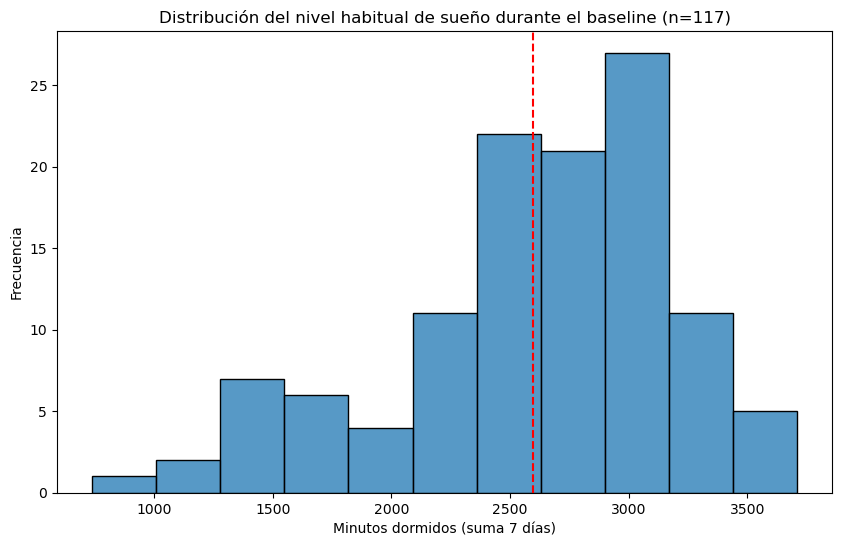

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_sleep, x="mean")
plt.axvline(baseline_sleep["mean"].mean(), color="red", linestyle="--")
plt.title("Distribución del nivel habitual de sueño durante el baseline (n=117)")
plt.xlabel("Minutos dormidos (suma 7 días)")
plt.ylabel("Frecuencia")
plt.show()


La distribución del nivel habitual de sueño está concentrada entre 2000 y 3500 minutos en ventana de 7 días, lo que corresponde aproximadamente a 4.7-8.3 horas por noche. La mayoría de los participantes se sitúan en la zona alta de la distribución, con un pico claro entre 2500 y 3000 minutos (5.9-7.1 horas/noche).

La distribución muestra asimetría hacia la izquierda: un pequeño grupo de participantes presenta baselines notablemente bajos (menos de 1500 minutos en ventana de 7 días, equivalente a menos de 3.6 horas/noche).

Esta lectura asume que la baseline calculada representa el patrón habitual estable de cada persona. Esta asunción no es trivial: los 21 días utilizados para construir el baseline podrían ya contener una transición o un proceso de cambio, en cuyo caso los valores observados no reflejarían la normalidad de la persona sino un estado ya alterado. 

El sistema aborda esta limitación con dos mecanismos posteriores: el sub-bloque 1.5 evalúa estadísticamente la estabilidad del baseline mediante pendiente y p-valor, y la decisión final de deterioro requiere convergencia en al menos 2 de las 3 dimensiones conductuales (sleep, activación, uso pasivo), lo que limita el peso de un baseline potencialmente contaminado en una única dimensión. Hasta esas validaciones, las interpretaciones de este histograma son condicionales.

**Distribución de la variabilidad individual**

Visualizamos la distribución de la columna `std` de `baseline_sleep` para caracterizar cuán regulares o irregulares son los patrones de sueño de los participantes durante los 21 días de baseline. Esta información condiciona la sensibilidad del sistema en la detección de desviaciones individuales en bloques posteriores.

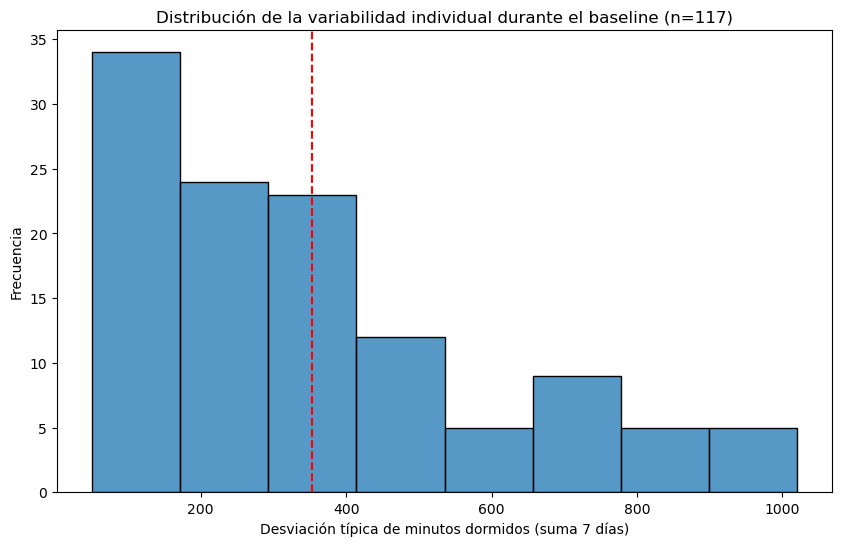

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_sleep, x="std")
plt.axvline(baseline_sleep["std"].mean(), color="red", linestyle="--")
plt.title("Distribución de la variabilidad individual durante el baseline (n=117)")
plt.xlabel("Desviación típica de minutos dormidos (suma 7 días)")
plt.ylabel("Frecuencia")
plt.show()

La distribución de la variabilidad individual está sesgada a la derecha. La mayoría de los participantes (más de 80 de 117) presentan std entre 0 y 400 minutos en la suma de 7 días. La media de la std (línea roja) se sitúa en torno a 350.

Una cola más larga muestra a unos 19 participantes con std superior a 600 minutos, llegando hasta valores cercanos a 1000.

La interpretación de esta std como "regularidad del patrón habitual" descansa en la misma asunción del histograma anterior: que los 21 días representan estabilidad. Si una persona tiene std alta porque su baseline coincide con un periodo de transición (deterioro en curso, recuperación, cambio de rutina), esa std no refleja su variabilidad normal sino la magnitud del cambio que estaba ocurriendo durante la ventana. La distinción entre "alta variabilidad estable" y "alta variabilidad por proceso en curso" no se puede hacer solo con la std. Se aborda con dos vías complementarias: el análisis de pendiente en 1.5, que detecta tendencias lineales sostenidas durante el baseline; y el criterio de convergencia entre dimensiones en bloques posteriores, que evita que una baseline ruidosa en sleep determine por sí sola la decisión de intervención.

**Relación entre nivel y variabilidad**

Visualizamos la relación entre las dos columnas de `baseline_sleep` mediante un scatter plot, con `mean` en el eje X y `std` en el eje Y. Esto permite identificar si existe asociación entre el nivel habitual de sueño y la regularidad del patrón, lo que tiene implicaciones para la interpretación del comportamiento individual y para el diseño del sistema de detección.

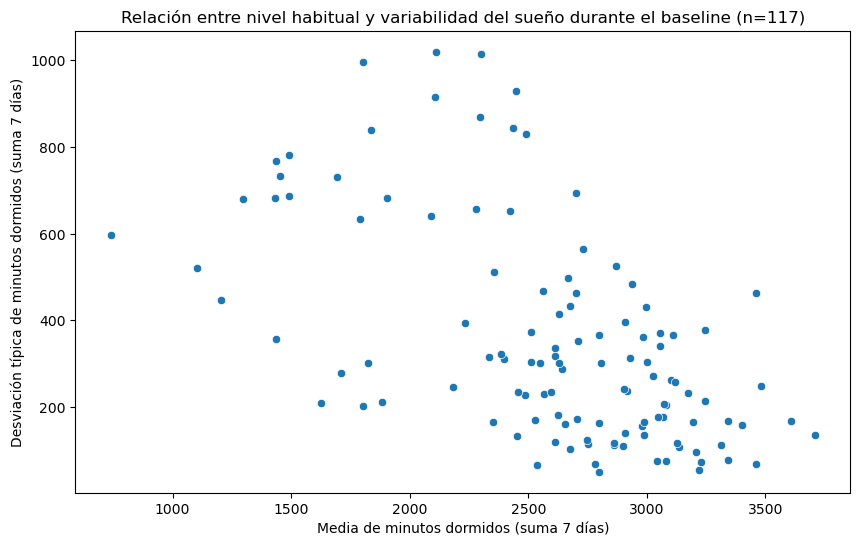

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_sleep, x="mean", y="std")
plt.title("Relación entre nivel habitual y variabilidad del sueño durante el baseline (n=117)")
plt.xlabel("Media de minutos dormidos (suma 7 días)")
plt.ylabel("Desviación típica de minutos dormidos (suma 7 días)")
plt.show()

El scatter plot muestra una correlación negativa visible entre el nivel habitual de sueño y la variabilidad individual: los participantes con `mean` alta (zona derecha, 2500-3500 minutos en suma de 7 días) tienden a presentar `std` baja (mayoritariamente por debajo de 400), mientras que los participantes con `mean` baja (zona izquierda, 1000-2000 minutos) presentan `std` notablemente mayor (muchos casos por encima de 600).

Esta asociación es relevante pero requiere cautela interpretativa. Una correlación negativa entre nivel y variabilidad puede tener dos lecturas distintas: que las personas con menos sueño habitual sean genuinamente más irregulares, o que en el grupo de sueño bajo haya una proporción mayor de baselines contaminados por procesos de cambio durante la ventana de medición. Sin distinguir entre ambas hipótesis, el sistema no puede asumir que el grupo de bajo nivel y alta variabilidad es homogéneo. La validación se construye en dos capas: primero, el análisis de pendiente en 1.5 identifica qué proporción de estos casos presenta tendencias significativas durante el baseline; segundo, el criterio de convergencia entre dimensiones aplicado en bloques posteriores garantiza que la decisión de deterioro no dependa de una única dimensión potencialmente sesgada. Las consecuencias para la sensibilidad del z-score se analizarán cuando estos datos estén disponibles.

#### 1.5. Cálculo de pendiente y p-valor

En este bloque, se valida la segunda capa del criterio de estabilidad del baseline: que durante los 21 días de la ventana no exista una tendencia sostenida que indique que la persona ya estaba cambiando antes de empezar el periodo de monitorización. Si esa tendencia existe, la baseline no representa la normalidad del participante sino una transición, y los estadísticos calculados en 1.4 (media y std) están sesgados.

Para detectar esa tendencia ajustamos una regresión lineal: trazamos la línea recta que mejor se ajusta a los 21 valores de `col_sleep` de cada participante a lo largo de los días, y miramos dos resultados. El primero es la pendiente de esa línea: si es positiva, la persona está aumentando su sueño durante el baseline; si es negativa, lo está reduciendo; si es cercana a cero, se mantiene estable. El segundo es el p-valor, que responde a una pregunta concreta: si en realidad no hubiera ninguna tendencia y la persona fuera completamente estable, ¿Qué probabilidad habría de observar por puro azar una pendiente como la que vemos? Cuando esa probabilidad es muy baja (por convención, menor o igual a 0.05), interpretamos que la pendiente observada no es casualidad sino un cambio real. Cuando es alta, asumimos que lo que vemos es ruido y la persona se mantiene estable. El criterio de decisión es directo: si p > 0.05, la baseline se considera estable; si p ≤ 0.05, se marca como inestable.

Ahora bien, el problema técnico es que las medidas que tenemos de cada persona no son independientes entre sí. Hay dos motivos que se suman. El primero es estructural: `col_sleep` es la suma deslizante de los 7 días anteriores, así que el valor del día 8 contiene 6 de los 7 días que ya estaban en el valor del día 7. Cada valor diario no es una observación nueva e independiente, sino una versión ligeramente actualizada del valor anterior. El segundo es propio del diseño longitudinal intra-sujeto: aunque la feature no fuera deslizante, las medidas repetidas sobre la misma persona a lo largo del tiempo están correlacionadas por la propia continuidad del comportamiento por "rachas" (alguien que duerme mal un día tiende a hacerlo también al siguiente). A esto se le llama autocorrelación. En el primer caso es una consecuencia matemática conocida de cómo está construida la feature; en el segundo es una propiedad inherente al diseño del estudio. Ambas vulneran la asunción de independencia que requiere la regresión lineal estándar.

La regresión lineal estándar asume que cada observación es independiente. Cuando esa asunción no se cumple, la pendiente estimada sigue siendo correcta, pero el cálculo de la incertidumbre alrededor de ella se queda corto. El sistema cree que tiene 21 datos independientes cuando en realidad tiene una secuencia altamente dependiente, y eso hace que el p-valor salga artificialmente bajo. En la práctica significa que la regresión nos dirá que hay tendencias significativas que en realidad son ruido. En un bloque cuyo único propósito es decidir sobre el p-valor, esto no es admisible.

La corrección estándar para este problema se llama HAC (Heteroskedasticity and Autocorrelation Consistent), también conocida como corrección de Newey-West. Su lógica es sencilla: en lugar de asumir que las observaciones son independientes, ajusta el cálculo de la incertidumbre teniendo en cuenta el grado de dependencia temporal entre ellas. La pendiente se calcula igual que en una regresión normal; lo que cambia es cómo se mide la confianza estadística en esa pendiente. El resultado es un p-valor honesto, no inflado por la dependencia temporal de las observaciones.

Se descartaron dos alternativas. La regresión dinámica modela explícitamente el patrón de dependencia temporal como un proceso aleatorio adicional que hay que estimar a partir de los datos. Es más sofisticada pero requiere muchos puntos para que esa estimación sea fiable, y con solo 21 valores por participante los parámetros quedan mal identificados. Además, en nuestro caso la dependencia no es un fenómeno aleatorio que necesitemos descubrir: sabemos exactamente de dónde viene (la suma deslizante de 7 días). Tratarla como si fuera aleatoria sería sobreingeniería. El test de Mann-Kendall es una alternativa no paramétrica que detecta tendencias sin asumir independencia, pero cambia el lenguaje del análisis: en lugar de hablar de pendiente y p-valor habla de tendencia monotónica creciente o decreciente, y eso obligaría a reescribir el resto del proyecto. HAC mantiene la coherencia con el lenguaje establecido en la consolidación y resuelve el problema técnico con una corrección puntual.

**Cálculo de pendiente y p-valor por participante con tratamiento de NaN**

Para cada participante con baseline fiable, ajustamos una regresión OLS de `col_sleep` sobre `day` con corrección HAC y extraemos pendiente y p-valor. La operación se hace participante por participante porque statsmodels no admite agrupación directa: usamos un bucle sobre `valid_pids_sleep` y guardamos los resultados en una lista de diccionarios que luego convertimos a DataFrame.

Hay un detalle técnico que requiere atención. Algunos participantes tienen entre 15 y 19 días válidos: pasaron el filtro de cobertura del 70% pero contienen NaN puntuales. `sm.OLS` no tolera NaN en la variable Y y devuelve NaN como resultado del modelo entero, lo que dejaría a esos participantes sin clasificar. La decisión adoptada es aplicar `.dropna()` dentro del bucle, antes de ajustar el modelo: cada participante se evalúa sobre los días válidos que efectivamente tiene.

In [33]:
resultados = []

for pid in valid_pids_sleep:
    datos = df_sleep_baseline_valid[df_sleep_baseline_valid["pid"] == pid].dropna(subset=[col_sleep])
    y = datos[col_sleep]
    X = sm.add_constant(datos["day"])
    
    modelo = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 7})
    
    resultados.append({
        "pid": pid,
        "slope": modelo.params.iloc[1],
        "p_value": modelo.pvalues.iloc[1]
    })

slope_sleep = pd.DataFrame(resultados).set_index("pid")
slope_sleep

,slope,p_value
pid,,
INS-W_001,-47.161039,3.481988e-06
INS-W_003,48.923377,1.849523e-01
INS-W_004,-17.136364,2.959207e-01
INS-W_005,6.989610,3.471208e-01
INS-W_006,-27.728571,2.401585e-09
...,...,...
INS-W_198,-119.216883,2.748039e-15
INS-W_201,-16.600000,6.528101e-01
INS-W_202,49.735714,6.424140e-03


`slope_sleep` contiene una fila por cada participante con baseline fiable, con su pendiente y su p-valor calculados sobre la ventana de 21 días. La pendiente está expresada en cambio de `col_sleep` por día. El p-valor procede del cálculo HAC y refleja la probabilidad de que la pendiente observada sea compatible con la hipótesis de no tendencia, una vez corregida la autocorrelación estructural.

Tras aplicar `.dropna()`, todos los participantes que pasaron el filtro de cobertura tienen ahora un valor numérico de pendiente y p-valor. Ya no quedan casos sin clasificar por motivos técnicos: cada participante se evalúa sobre los días válidos que efectivamente tiene en su ventana de baseline.

**Identificación de participantes con baseline inestable**

Aplicamos el criterio de estabilidad: un baseline se considera estable si su p-valor es mayor que 0.05. Identificamos los participantes con baseline inestable (p ≤ 0.05) para decidir cómo tratarlos. Cuantificamos cuántos pasan el filtro y cuántos no.

In [34]:
unstable_pids_sleep = slope_sleep[slope_sleep["p_value"] <= 0.05].index
stable_pids_sleep = slope_sleep[slope_sleep["p_value"] > 0.05].index

print(f"Participantes con baseline estable (p > 0.05): {len(stable_pids_sleep)}")
print(f"Participantes con baseline inestable (p ≤ 0.05): {len(unstable_pids_sleep)}")

Participantes con baseline estable (p > 0.05): 59
Participantes con baseline inestable (p ≤ 0.05): 58


La aplicación del criterio de estabilidad divide a los participantes con baseline fiable de sleep en dos grupos. El grupo de baselines estables (p > 0.05) está formado por participantes cuyo patrón de sueño durante los 21 días iniciales no muestra una tendencia lineal significativa una vez corregida la autocorrelación: su sleep se comportó de forma estable durante esa ventana, y por tanto la media y la std calculadas en 1.4 son una referencia individual fiable.

El grupo de baselines inestables (p ≤ 0.05) está formado por participantes cuyo sueño sí presenta tendencia significativa durante los 21 días iniciales. Para esos participantes, los 21 días no representan un patrón estable sino una transición. Esto no significa que estén deteriorándose: significa que su ventana inicial coincidió con un proceso de cambio (transición académica, adaptación al wearable, evento puntual sostenido, recuperación tras un episodio previo) cuyo origen no podemos discriminar solo con la pendiente. La clasificación de detectabilidad se aplica en consecuencia: estos participantes no entran todavía en el pipeline automático de monitorización en la dimensión sleep.

**Análisis del patrón de los inestables**

De los participantes marcados como inestables, miramos si su pendiente es positiva (subida durante el baseline, posible recuperación) o negativa (bajada durante el baseline, posible deterioro en curso). Esto informa la decisión sobre qué hacer con ellos.

In [35]:
inestables = slope_sleep.loc[unstable_pids_sleep]
n_subida = (inestables["slope"] > 0).sum()
n_bajada = (inestables["slope"] < 0).sum()

print(f"De los {len(unstable_pids_sleep)} inestables:")
print(f"  - Pendiente positiva (subida durante baseline): {n_subida}")
print(f"  - Pendiente negativa (bajada durante baseline): {n_bajada}")

De los 58 inestables:
  - Pendiente positiva (subida durante baseline): 27
  - Pendiente negativa (bajada durante baseline): 31


La distribución entre pendientes positivas y negativas dentro del grupo inestable informa sobre la naturaleza del cambio observado durante el baseline. Una distribución muy asimétrica hacia un solo lado sugeriría un fenómeno común a la cohorte (por ejemplo, una mejora generalizada del sueño tras la primera semana, compatible con adaptación al estudio, o una caída generalizada compatible con un periodo académico exigente). Una distribución equilibrada entre ambos signos sugiere que el cambio durante la ventana inicial no responde a una causa común, sino a procesos individuales heterogéneos.

En cualquiera de los dos casos, la decisión operativa es la misma: el sistema no construye un baseline definitivo sobre una ventana en transición. La política de detectabilidad mantiene a estos participantes en background: el sistema sigue recogiendo datos y reevaluará el criterio de estabilidad cuando avance la línea temporal, hasta que el patrón de sueño se estabilice y permita establecer un baseline fiable.

**Visualización slope vs p-valor**

Visualizamos la relación entre pendiente y p-valor de los 117 participantes. La línea horizontal en p=0.05 marca el umbral de decisión. Los puntos por debajo son baselines inestables; los puntos por encima son estables. Esta vista permite ver si los inestables se concentran en alguna zona concreta de pendiente o si se distribuyen uniformemente.

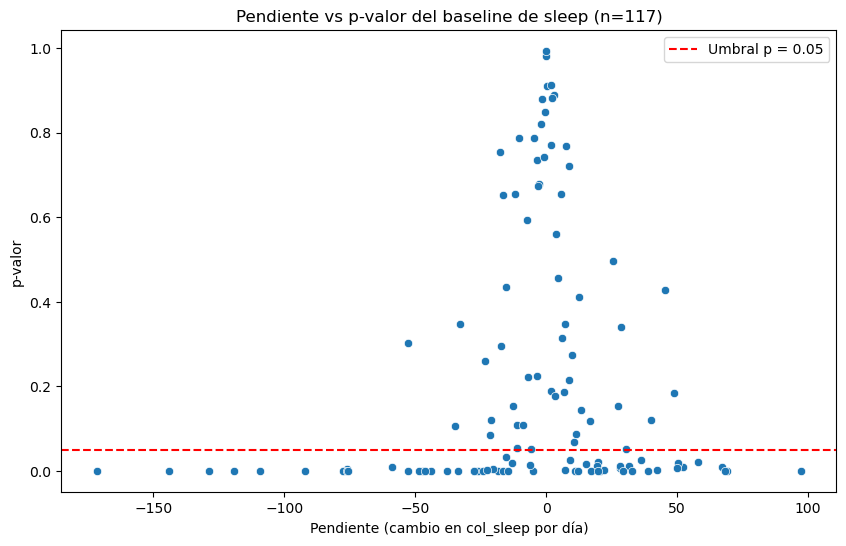

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=slope_sleep, x="slope", y="p_value")
plt.axhline(0.05, color="red", linestyle="--", label="Umbral p = 0.05")
plt.title("Pendiente vs p-valor del baseline de sleep (n=117)")
plt.xlabel("Pendiente (cambio en col_sleep por día)")
plt.ylabel("p-valor")
plt.legend()
plt.show()

El scatter plot permite leer la estructura conjunta de las dos magnitudes que definen la estabilidad del baseline. Los puntos por encima de la línea roja (p > 0.05) son los baselines estables: independientemente de su pendiente, no hay evidencia estadística de tendencia significativa en su ventana inicial. Los puntos por debajo de la línea son los inestables: su pendiente es estadísticamente distinguible de cero.

La forma típica de este gráfico es un patrón en forma de embudo invertido: las pendientes muy próximas a cero quedan altas (p-valor alto, no significativo), y a medida que la pendiente se aleja de cero por cualquiera de los dos lados, los puntos descienden hacia p-valores bajos. Una concentración fuerte de puntos en uno de los dos cuadrantes inferiores (positivo o negativo) reforzaría la lectura del análisis anterior sobre patrones direccionales en la cohorte. La distribución entre los dos cuadrantes inferiores es, en esta muestra, lo que el conteo del bloque anterior cuantifica.

**Actualización de `baseline_sleep` con los participantes detectables en sleep**

`baseline_sleep` se actualiza para conservar únicamente los participantes con baseline estable en sleep. No se borra a los inestables del proyecto: pueden tener baseline fiable en otras dimensiones (steps, location, screen) y participar en la decisión de detectabilidad global mediante la regla de convergencia 2/3. Los participantes que no superen el filtro de estabilidad en al menos 2 dimensiones permanecerán en background sin entrar en monitorización automática, hasta que su patrón se estabilice en el tiempo.

In [38]:
baseline_sleep = baseline_sleep.loc[stable_pids_sleep]
baseline_sleep

,mean,std
pid,,
INS-W_003,1902.666667,683.105287
INS-W_004,2930.142857,312.965379
INS-W_005,3340.190476,167.883477
INS-W_009,2625.904762,182.670442
INS-W_010,2395.523810,310.473126
INS-W_012,2547.619048,300.572200
INS-W_013,3000.047619,304.316854
INS-W_015,3402.857143,157.487551
INS-W_019,1490.421053,781.686874


### Cierre del baseline de sleep

El baseline individual de sleep queda construido para el subconjunto de participantes que han superado los dos criterios de estabilidad: cobertura mínima del 70% sobre la ventana inicial de 21 días y ausencia de tendencia significativa con corrección HAC. Para estos participantes, `baseline_sleep` contiene la media y la desviación típica que servirán de referencia individual en el cálculo del z-score intra-sujeto en bloques posteriores.

Los participantes que no han superado los criterios no se descartan. La política de detectabilidad establecida en el diseño del Bloque 2 indica que estos casos permanecen en background: el sistema sigue recogiendo datos y reevaluará el criterio de estabilidad de forma periódica hasta que el patrón se estabilice. La decisión final sobre si un participante entra o no en monitorización automática se toma de forma global, una vez calculados los baselines de las cuatro dimensiones (sleep, steps, location, screen), aplicando la regla de convergencia 2/3 sobre dimensiones detectables.

El siguiente paso es replicar este mismo procedimiento sobre la dimensión de activación (steps), repitiendo la misma lógica: identificación de la feature primaria, filtrado de la ventana, evaluación de cobertura, cálculo de media y std, y validación de estabilidad mediante pendiente con corrección HAC.